In [41]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [89]:
df = pd.read_csv('..\\data\\mega_FA_bathy.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,FA,ps_z,stein_z,bathy
0,49.62,-129.98,0.816961,366.0,523.431597,564.247252,2.029732,2816.350677,2929.908563,-2408
1,44.68,-125.29,9.119624,79.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2114
2,44.66,-125.27,9.119624,81.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
3,44.66,-125.27,9.119624,93.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2269
4,44.66,-125.26,9.119624,77.0,156.665075,168.881356,-66.546684,3556.955038,3702.253111,-2280


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [90]:
x = df.drop(columns=['q_ps', 'q_stein', 'ps_z', 'stein_z', 'FA'])
y = df['FA']

In [91]:
x.head()

,lat,long,age,q_ihfc,bathy
0,49.62,-129.98,0.816961,366.0,-2408
1,44.68,-125.29,9.119624,79.0,-2114
2,44.66,-125.27,9.119624,81.0,-2269
3,44.66,-125.27,9.119624,93.0,-2269
4,44.66,-125.26,9.119624,77.0,-2280


In [92]:
x.shape

(7445, 5)

In [ ]:
y.head()

0     2.029732
1   -66.546684
2   -66.546684
3   -66.546684
4   -66.546684
Name: FA, dtype: float64

In [94]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [95]:
x_train.shape

(5956, 5)

this is the raw validation data

In [96]:
x_test.shape

(1489, 5)

In [97]:
x_train.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,5956.000,5956.000,5956.000,5956.000,5956.000
mean,46.178,-125.711,6.241,595.876,-1226.233
std,3.549,3.569,5.966,1565.286,1684.928
min,37.030,-132.420,0.021,-169.400,-4764.000
25%,44.532,-128.680,0.817,87.000,-2583.000
50%,47.860,-127.650,3.579,189.000,-2408.000
75%,48.450,-122.440,9.544,414.097,590.750
max,54.940,-119.000,35.200,25680.000,2860.000


In [98]:
x_test.describe().round(3)

,lat,long,age,q_ihfc,bathy
count,1489.000,1489.000,1489.000,1489.000,1489.000
mean,46.170,-125.832,6.233,660.786,-1297.577
std,3.548,3.516,6.112,2000.706,1681.300
min,37.060,-132.370,0.010,-182.200,-4568.000
25%,44.620,-128.680,0.817,84.000,-2587.000
50%,47.850,-127.720,3.371,192.000,-2437.000
75%,48.450,-122.660,9.545,411.000,507.000
max,54.900,-119.000,31.245,26000.000,2104.000


In [99]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

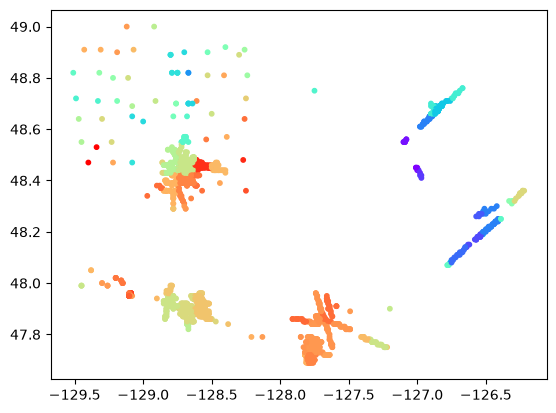

In [56]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

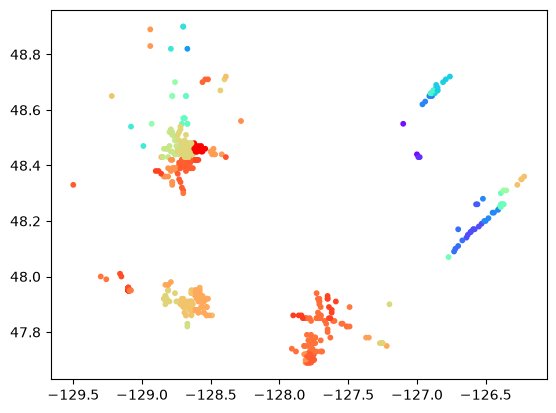

In [57]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [100]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [101]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002610 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1238
[LightGBM] [Info] Number of data points in the train set: 5956, number of used features: 5
[LightGBM] [Info] Start training from score -6.962150


In [102]:
y_pred = model.predict(x_test)

In [103]:
y_pred.shape

(1489,)

In [104]:
y_pred, y_pred.shape

(array([-23.90916983, -34.31512267,  -0.24230598, ..., -39.50683082,
        -24.33742807, -29.7702509 ], shape=(1489,)),
 (1489,))

In [105]:
residuals = y_test - y_pred

negative mean: overpredicting

In [108]:
residuals.head(), residuals.describe()

(3728    -5.755013
 2494    10.323965
 2304    -2.058002
 5893     4.730211
 2513    -0.765928
 Name: FA, dtype: float64,
 count    1489.000000
 mean        0.435536
 std        10.510966
 min       -51.734636
 25%        -1.635162
 50%        -0.140069
 75%         1.905052
 max        71.024420
 Name: FA, dtype: float64)

In [109]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [112]:
pd.DataFrame(dfr).to_csv('..\\created_data\\bth_grav_residuals.csv', index=False)

with open('..\\created_data\\bth_grav_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'and this was for lat, long, age, ihfc, and bathy')

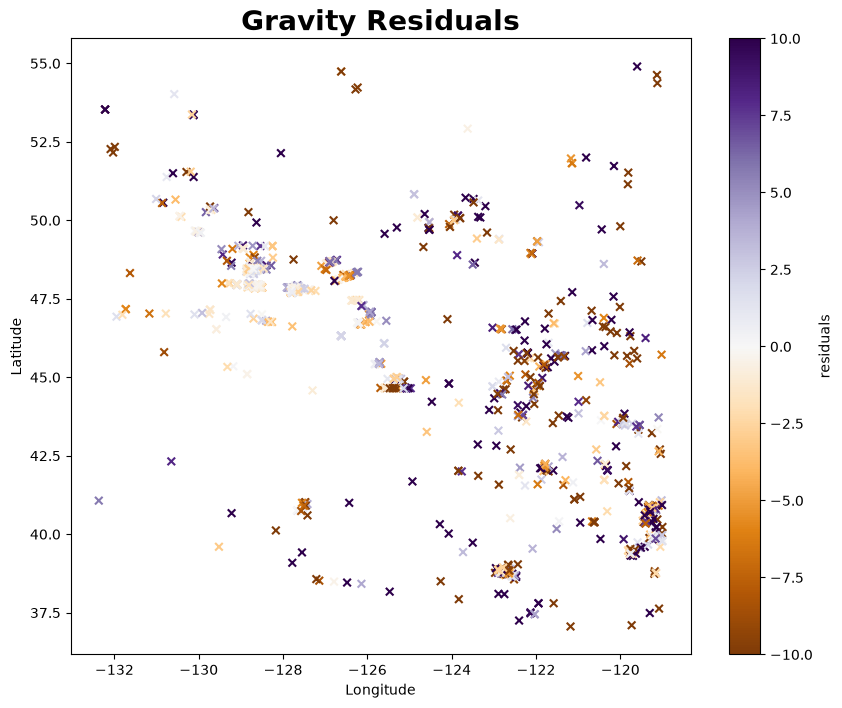

In [114]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-10, vmax=10)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity Residuals', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\grav\\bath_res_grav.png', dpi=400)
plt.show()

## now we ... predict!

In [115]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [116]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [117]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [118]:
age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')
bathy_interp = griddata((df['long'], df['lat']), df['bathy'], (long, lat), method='linear')

In [119]:
np.where(~np.isnan(age_interp))

(array([  0,   0,   0, ..., 249, 249, 249], shape=(59923,)),
 array([181, 182, 183, ..., 244, 245, 246], shape=(59923,)))

In [120]:
hf_interp[130:135, 130:135], age_interp[130:135, 130:135], bathy_interp[130:135, 130:135]

(array([[76.19973119, 74.29876331, 72.39779543, 70.49682755, 68.59585967],
        [76.84437386, 74.94340598, 73.04243809, 71.14147021, 69.24050233],
        [77.48901652, 75.58804864, 73.68708076, 71.78611288, 69.88514499],
        [78.13365918, 76.2326913 , 74.33172342, 72.43075554, 70.52978766],
        [78.77830184, 76.87733396, 74.99226332, 73.20379947, 71.41533562]]),
 array([[8.50123656, 8.56170337, 8.62217018, 8.68263699, 8.7431038 ],
        [8.52187179, 8.5823386 , 8.64280541, 8.70327222, 8.76373903],
        [8.54250703, 8.60297384, 8.66344065, 8.72390746, 8.78437427],
        [8.56314227, 8.62360908, 8.68407589, 8.7445427 , 8.80500951],
        [8.5837775 , 8.64424431, 8.70314332, 8.75251489, 8.80188645]]),
 array([[-1815.91977819, -1718.71829848, -1621.51681877, -1524.31533906,
         -1427.11385936],
        [-1789.52180833, -1692.32032862, -1595.11884891, -1497.91736921,
         -1400.7158895 ],
        [-1763.12383847, -1665.92235876, -1568.72087906, -1471.51939935,


In [121]:
age_interp.shape, hf_interp.shape, bathy_interp.shape

((250, 250), (250, 250), (250, 250))

np.vstack stacks arrays as new rows

In [124]:
lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel(), bathy_interp.ravel()]).T

In [125]:
lola.shape

(62500, 5)

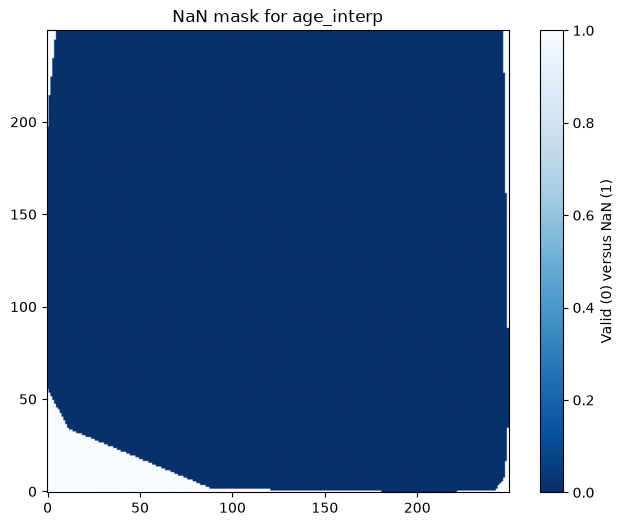

In [126]:
np.where(np.isnan(lola))

plt.figure(figsize=(8,6))
plt.imshow(np.isnan(age_interp), origin='lower', cmap='Blues_r', vmin=0, vmax=1)
plt.title('NaN mask for age_interp')
plt.colorbar(label='Valid (0) versus NaN (1)')
plt.show()

In [127]:
lola_pred = model.predict(lola)

In [129]:
lola_pred[180:184]

array([ 9.49248457, -5.10522242, -5.10522242, -5.10522242])

In [130]:
lola_pred = lola_pred.reshape(long.shape)

In [131]:
lola_pred.shape

(250, 250)

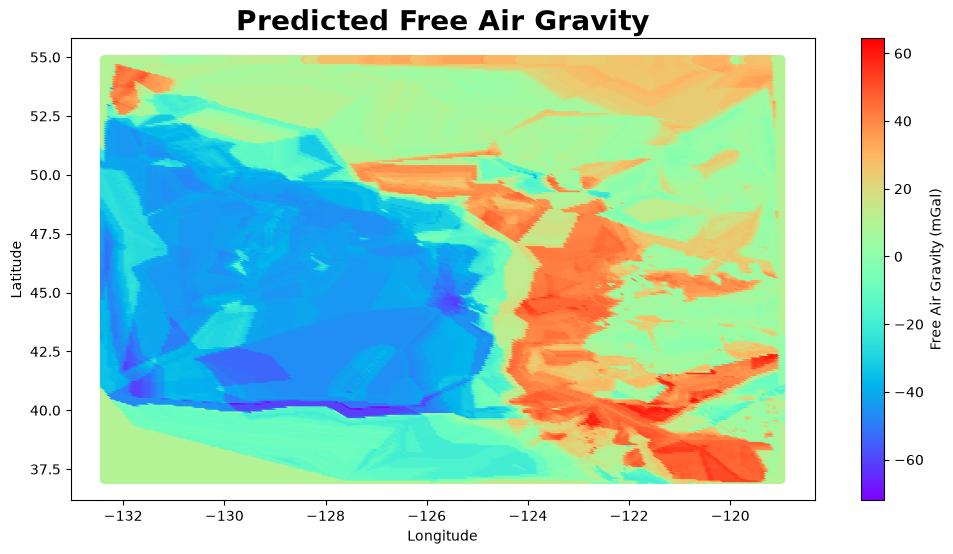

In [132]:
plt.figure(figsize=(12, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Free Air Gravity', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig(f'..\\figs\\grav\\bth_grav_pred_{sp}.png', dpi=400)
plt.show()

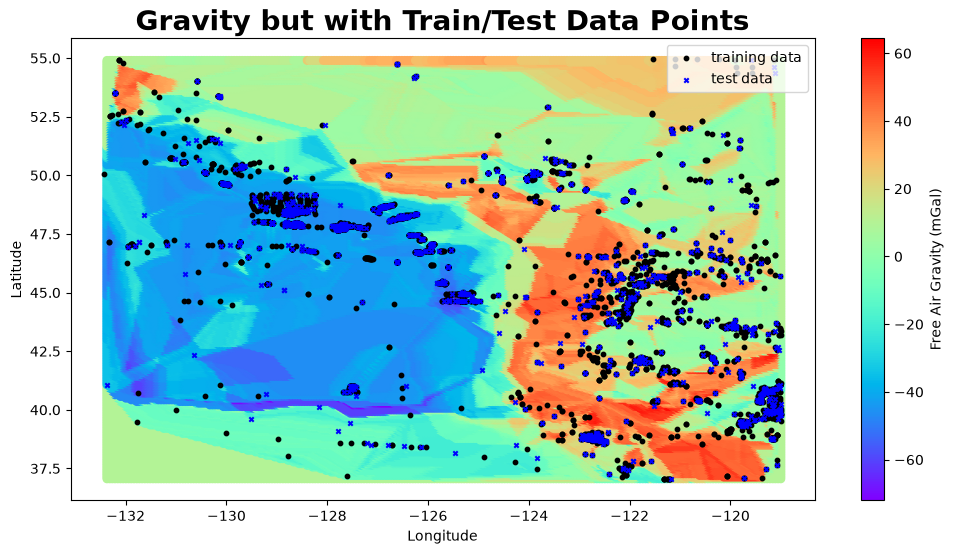

In [133]:
plt.figure(figsize=(12,6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Free Air Gravity (mGal)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=10, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=10, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Gravity but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')

plt.savefig(f'..\\figs\\grav\\bth_grav_pnts_pred_{sp}.png', dpi=400)
plt.show()